In [7]:
# %% [markdown]
# # 1. Imports and Experiment Setup
# Import the necessary libraries. 
# We use MNE for processing, YASA for sleep ML, and PyOD for spike detection.

# %%
import mne
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yasa
import seaborn as sns
from mne.preprocessing import ICA
from mne_icalabel import label_components
from pyod.models.iforest import IForest
import warnings

# --- Configuration ---
warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

# Experiment Variables
PATIENT = "XU"
DBS_FREQ = 7           # The stimulation frequency
LINE_FREQ = 60         # Powerline noise
TARGET_CH = 'Cz'       # Preferred channel for analysis
FILE_PATH = f"../data/{PATIENT}/{PATIENT}SLEEP{DBS_FREQ}.EDF" # Select file

print(f"Pipeline initialized for Patient {PATIENT} with {DBS_FREQ}Hz DBS.")

Pipeline initialized for Patient XU with 7Hz DBS.


Loaded 46 channels: ['Fp1', 'F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 'A1', 'Fz', 'Cz', 'Fp2', 'F8', 'T4', 'T6', 'O2', 'F4', 'C4', 'P4', 'A2', 'Fpz', 'Pz', 'T1', 'T2', 'EKGL', 'EKGR', 'LOC1', 'LOC2', 'EMG1', 'EMG2', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'DC1', 'DC2', 'DC3', 'DC4', 'OSAT', 'PR']


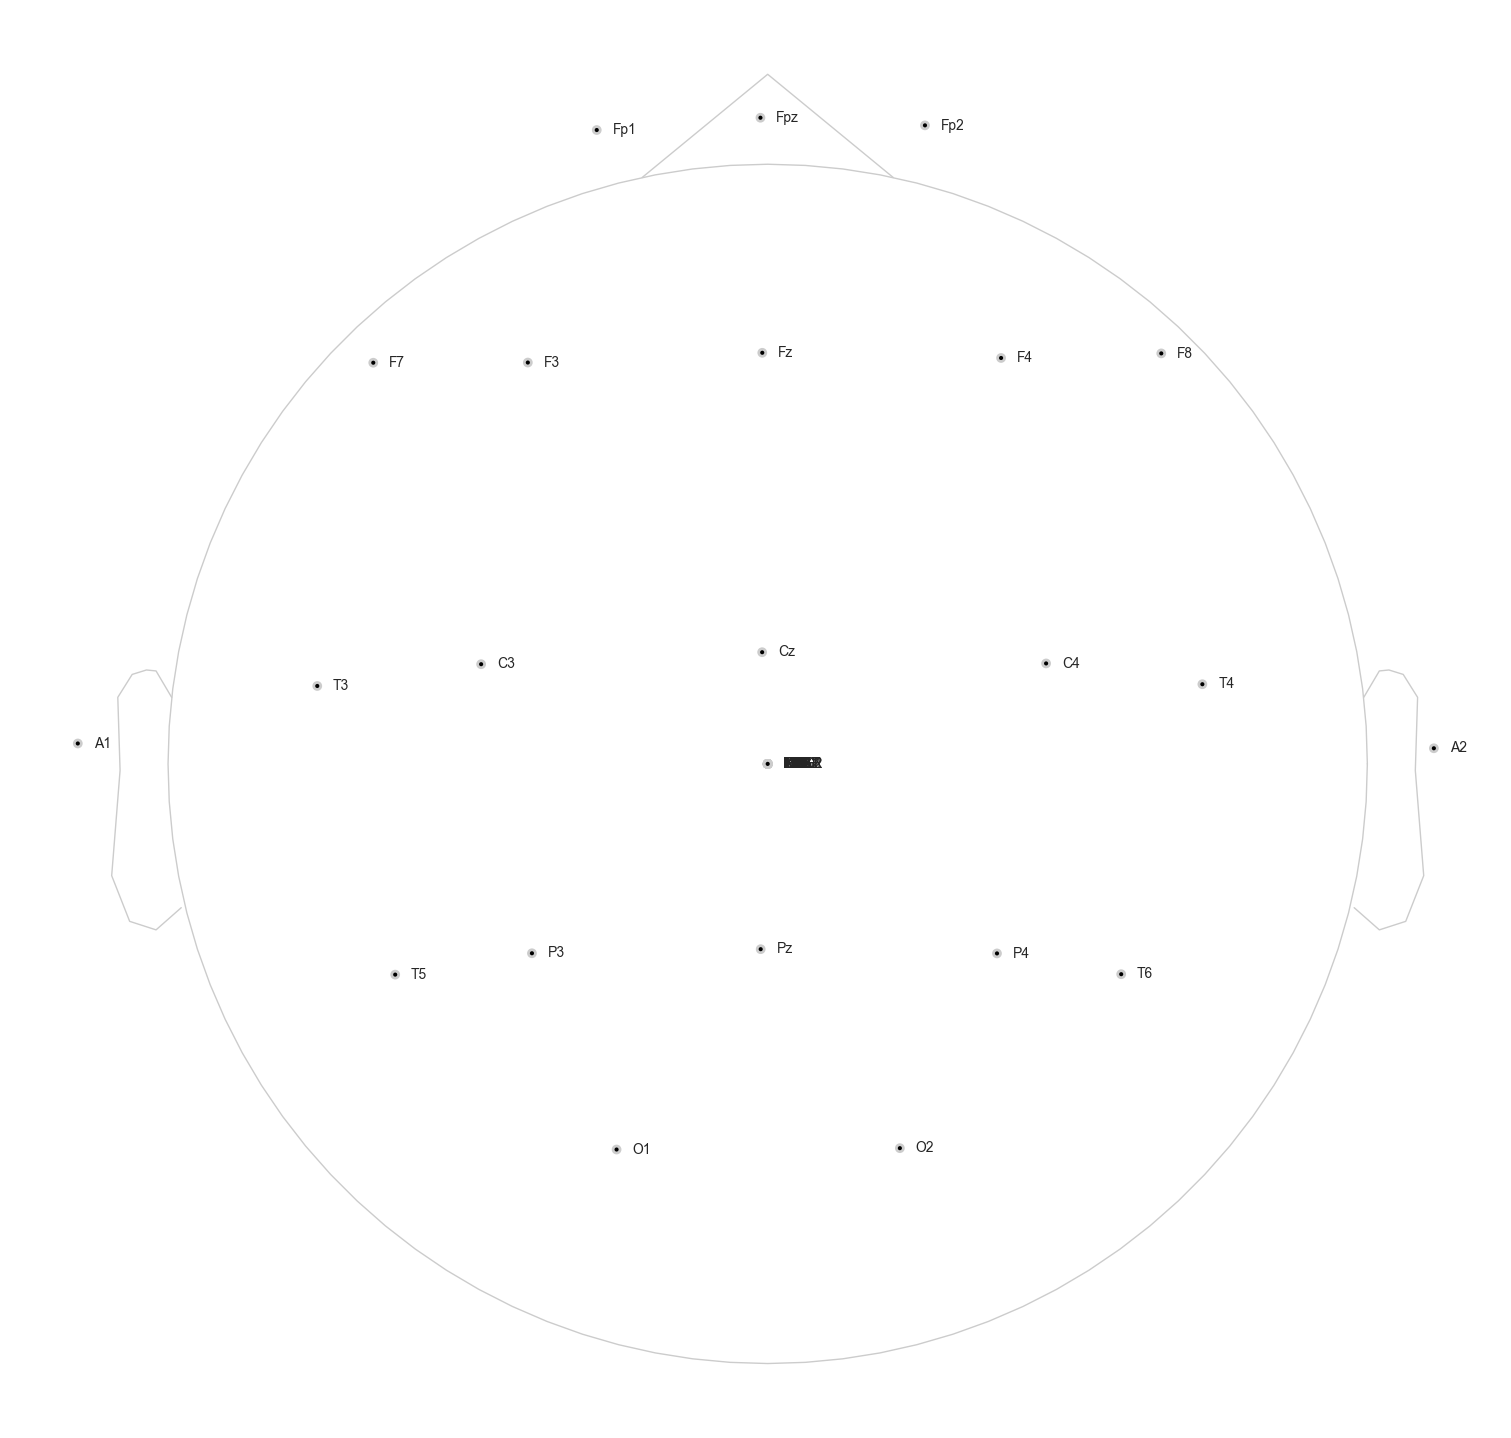

In [8]:
# %% [markdown]
# # 2. Load Data & Set Montage
# We load the EDF and force the standard 10-20 montage.

# %%
# Load Data
raw = mne.io.read_raw_edf(FILE_PATH, preload=True)

# 1. Set Montage (Crucial for AI models)
try:
    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage, on_missing='warn')
except Exception as e:
    print(f"Montage warning: {e}")

# 2. Fix Channel Types
# Ensure MNE treats them as EEG, not 'misc'
ch_types = {}
for ch in raw.ch_names:
    if ch in montage.ch_names:
        ch_types[ch] = 'eeg'
raw.set_channel_types(ch_types)

print(f"Loaded {len(raw.ch_names)} channels: {raw.ch_names}")
raw.plot_sensors(show_names=True)
plt.show()

In [9]:
# %% [markdown]
# # 3. Calculate Artifact Frequencies
# We mathematically define every frequency peak we need to remove.

# %%
sfreq = raw.info['sfreq']
nyquist = sfreq / 2

# Generate DBS harmonics (7, 14, 21...)
dbs_harmonics = np.arange(DBS_FREQ, nyquist, DBS_FREQ)

# Generate Line harmonics (60, 120, 180...)
line_harmonics = np.arange(LINE_FREQ, nyquist, LINE_FREQ)

# Combine and sort unique frequencies
freqs_to_remove = np.unique(np.concatenate([dbs_harmonics, line_harmonics]))

print(f"Identified {len(freqs_to_remove)} specific frequencies to remove.")
print(f"Sample: {freqs_to_remove[:10]} ... Hz")

Identified 20 specific frequencies to remove.
Sample: [ 7. 14. 21. 28. 35. 42. 49. 56. 60. 63.] ... Hz


TypeError: Got unexpected keyword argument label for PSD method "welch".

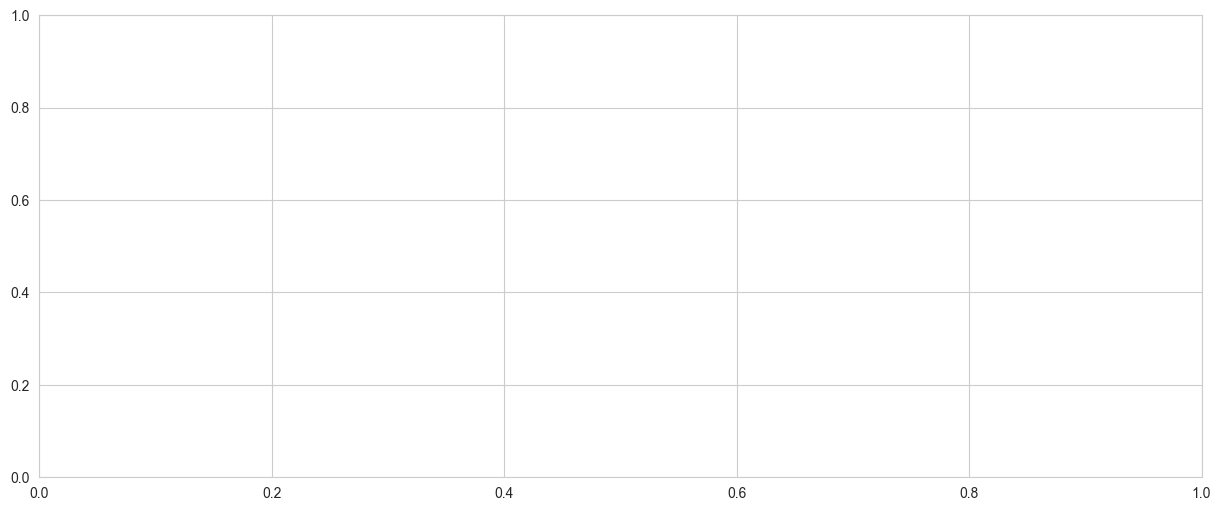

In [10]:
# %% [markdown]
# # 4. DBS Artifact Removal
# We apply a high-pass filter (1Hz) for stability, then notch out the DBS frequencies.

# %%
raw_dbs_clean = raw.copy()

# 1. High Pass (Standard for ICA stability)
raw_dbs_clean.filter(l_freq=1.0, h_freq=None)

# 2. Notch Filter (Spectrum Fit)
# This removes the sharp peaks defined in Cell 3
raw_dbs_clean.notch_filter(freqs=freqs_to_remove, method='spectrum_fit', n_jobs=1)

# VISUAL CHECK: Plot PSD
fig, ax = plt.subplots()
raw.plot_psd(fmax=45, ax=ax, color='gray', show=False, label='Original')
raw_dbs_clean.plot_psd(fmax=45, ax=ax, color='red', show=False, label='Cleaned')
ax.set_title("PSD: Before vs After DBS Removal")
ax.legend()
plt.show()